feature scaling is a technique used in machine learning to standardize the range of independent variables or features of data. It is important because many machine learning algorithms perform better when the features are on a similar scale.

# Standardization (Z-score normalization)
Standardization, also known as Z-score normalization, transforms the data to have a mean of 0 and a standard deviation of 1. This is done by subtracting the mean from each feature and then dividing by the standard deviation.
X_scaled = (X - X.mean()) / X.std()


In [38]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [39]:
df=pd.read_csv('./Social_Network_Ads.csv')

In [40]:
df=df.iloc[:,2:]

In [41]:
df.sample(5)

,Age,EstimatedSalary,Purchased
231,39,42000,0
356,54,70000,1
8,25,33000,0
240,42,149000,1
387,39,71000,0


# train test split

In [42]:
!pip install scikit-learn

In [43]:
from sklearn.model_selection import train_test_split
X_train ,X_test,Y_train,Y_test=train_test_split(df.drop('Purchased',axis=1),df['Purchased'],train_size=0.3,random_state=0)
X_train.shape,X_test.shape

((120, 2), (280, 2))

# Standard Scaler

In [44]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
X_train_Scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [45]:
scaler.mean_

array([3.71500000e+01, 6.70833333e+04])

In [46]:
X_train_Scaled=pd.DataFrame(X_train_Scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [47]:
X_train_Scaled

,Age,EstimatedSalary
0,0.281809,0.230103
1,-0.410353,-1.135984
2,0.677330,2.090307
3,-1.498037,-1.426640
4,-0.410353,-0.467473
...,...,...
115,1.072852,-1.077852
116,-0.805875,-0.699998
117,-0.113712,-0.438407
118,-1.003635,-0.380276


In [48]:
np.round(X_train_Scaled.describe(),1)

,Age,EstimatedSalary
count,120.0,120.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.5
25%,-0.7,-0.8
50%,-0.0,-0.1
75%,0.5,0.5
max,2.3,2.4


# Effect of Scaling

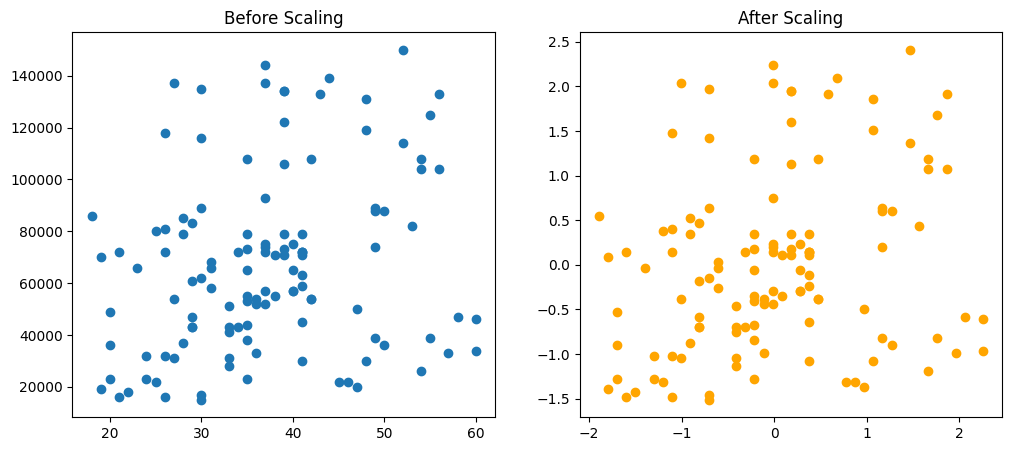

In [49]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(X_train_Scaled['Age'],X_train_Scaled['EstimatedSalary'],color='orange')
ax2.set_title('After Scaling')
plt.show()

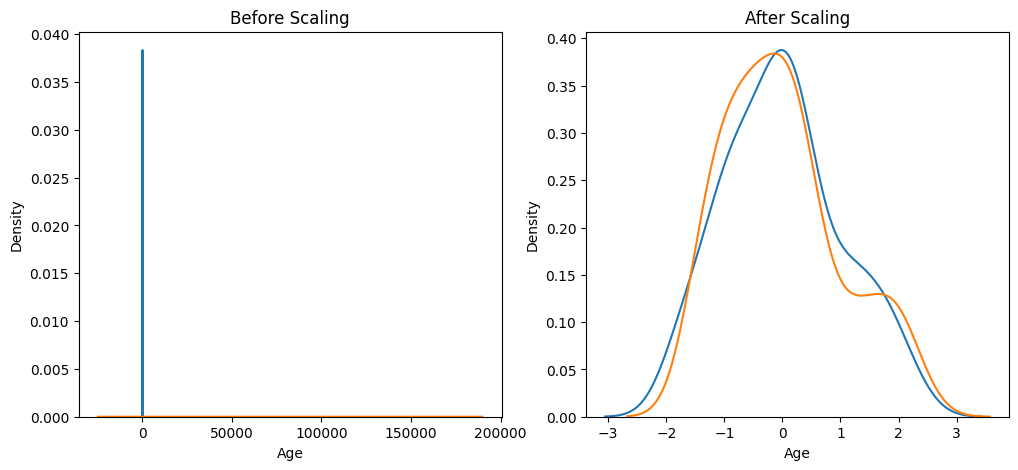

In [50]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'],ax=ax1) 
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)
ax2.set_title('After Scaling')
sns.kdeplot(X_train_Scaled['Age'],ax=ax2)
sns.kdeplot(X_train_Scaled['EstimatedSalary'],ax=ax2)
plt.show()

# comparision of distribution before and after scaling

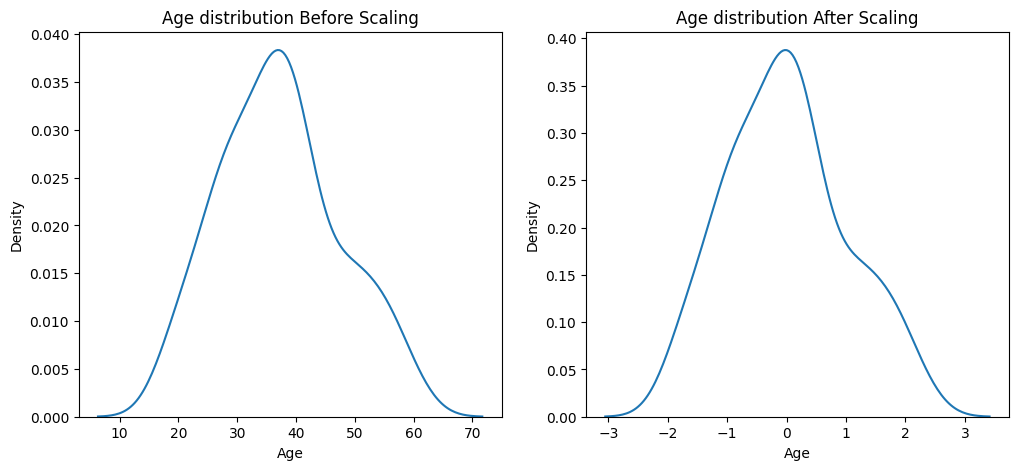

In [51]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Age distribution Before Scaling')
sns.kdeplot(X_train['Age'],ax=ax1) 
ax2.set_title('Age distribution After Scaling')
sns.kdeplot(X_train_Scaled['Age'],ax=ax2)
plt.show()

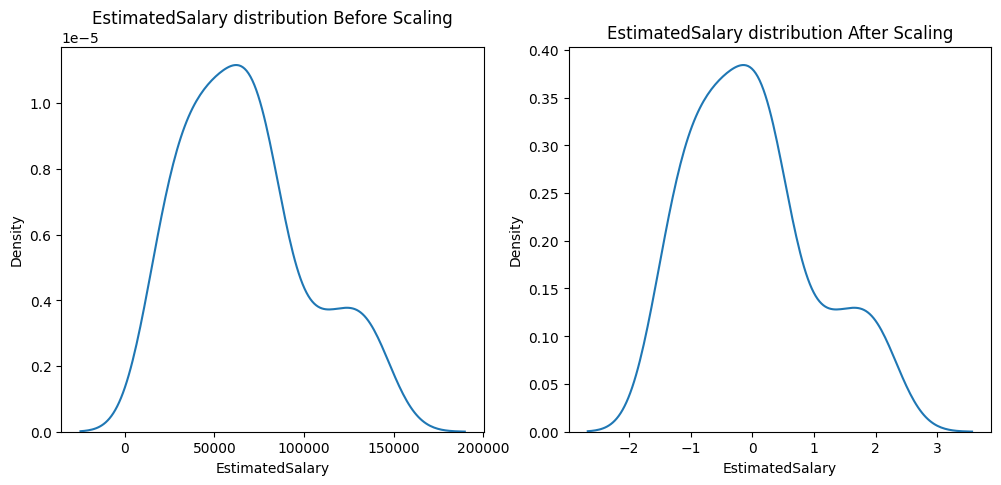

In [52]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('EstimatedSalary distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1) 
ax2.set_title('EstimatedSalary distribution After Scaling')
sns.kdeplot(X_train_Scaled['EstimatedSalary'],ax=ax2)
plt.show()

# Why scaling is important? 

In [53]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model_scaled=LogisticRegression()
model.fit(X_train,Y_train)
model.score(X_test,Y_test)
model_scaled.fit(X_train_Scaled,Y_train)
model_scaled.score(X_test_scaled,Y_test)

0.7821428571428571

In [54]:
from sklearn.metrics import accuracy_score

y_pred=model.predict(X_test)
y_pred_scaled=model_scaled.predict(X_test_scaled)
print('Before Scaling', accuracy_score(Y_test, y_pred))
print('After Scaling',accuracy_score(Y_test,y_pred_scaled))

Before Scaling 0.7964285714285714
After Scaling 0.7821428571428571


# Effect of outliers on scaling

In [56]:
new_rows = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary': [1000, 250000, 350000],
    'Purchased': [0, 1, 1]
})
df = pd.concat([df, new_rows], ignore_index=True)

In [57]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


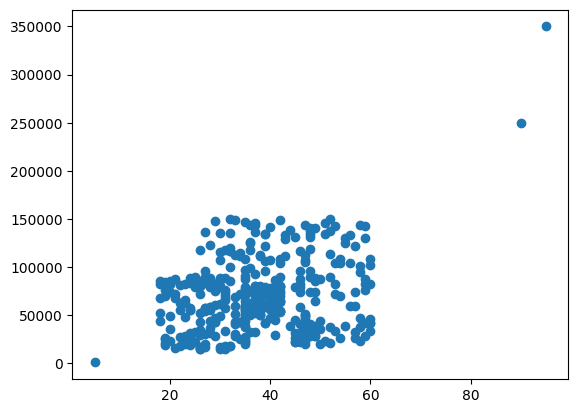

In [58]:
plt.scatter(df['Age'],df['EstimatedSalary'])